In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\SHALINI\Downloads\Ecommerce_Sales_Data_2024_2025.csv")
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [4]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [5]:
column = 'Sales'

mean_val = df[column].mean()
median_val = df[column].median()
mode_val = df[column].mode()[0]
std_val = df[column].std()
skew_val = df[column].skew()

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)
print("Standard Deviation:", std_val)
print("Skewness:", skew_val)

Mean: 106733.20487
Median: 83080.325
Mode: 6458.4
Standard Deviation: 85108.2082018013
Skewness: 0.9531984630367376


In [6]:
numeric_cols = ['Sales', 'Profit', 'Quantity', 'Unit Price', 'Discount']

summary = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Std Dev': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew()
})

summary

,Mean,Median,Mode,Std Dev,Skewness
Sales,106733.204870,83080.325,6458.40,85108.208202,0.953198
Profit,15941.746982,11108.525,765.58,14897.684916,1.504734
Quantity,2.992600,3.000,4.00,1.413133,-0.006055
Unit Price,39760.904600,39459.500,804.00,22831.783946,0.023700
Discount,10.051000,10.000,20.00,7.084662,-0.008309


In [7]:
for col in numeric_cols:
    skew_value = df[col].skew()
    if skew_value > 0.5:
        interpretation = "Right-skewed (long tail of high values)"
    elif skew_value < -0.5:
        interpretation = "Left-skewed (long tail of low values)"
    else:
        interpretation = "Roughly symmetric"
    print(f"{col}: skewness = {skew_value:.2f} → {interpretation}")

Sales: skewness = 0.95 → Right-skewed (long tail of high values)
Profit: skewness = 1.50 → Right-skewed (long tail of high values)
Quantity: skewness = -0.01 → Roughly symmetric
Unit Price: skewness = 0.02 → Roughly symmetric
Discount: skewness = -0.01 → Roughly symmetric


In [8]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')


T-Test (Compare Two Groups)

In [9]:
print(df['Region'].unique())
print(df['Category'].unique())

['South' 'North' 'East' 'West']
['Books' 'Groceries' 'Kitchen' 'Clothing' 'Furniture' 'Beauty'
 'Home Decor' 'Electronics' 'Sports' 'Toys']


In [10]:
group_a = df[df['Region'] == 'East']['Sales']
group_b = df[df['Region'] == 'West']['Sales']

t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference in Sales between East and West.")
else:
    print("No significant difference.")

T-statistic: 0.747
P-value: 0.4552
No significant difference.


Chi-Square Test — Relationship Between Two Categorical Columns

In [11]:
contingency_table = pd.crosstab(df['Category'], df['Payment Mode'])
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("There IS a significant relationship between Category and Payment Mode.")
else:
    print("No significant relationship — they are independent.")

Payment Mode  COD  Credit Card  Debit Card  Net Banking  UPI
Category                                                    
Beauty         91           89          92           96   92
Books         106          117         118          101   86
Clothing      108           93         100          101  109
Electronics    95           93          91          106   87
Furniture      80          100         134           95  118
Groceries      89          104          98           90   89
Home Decor    114           96          92          107  106
Kitchen       105          104         104          104  111
Sports        113          106          82          103  107
Toys          104           92          92          107   83
Chi-square statistic: 41.894
P-value: 0.2304
No significant relationship — they are independent.


Confidence Interval (for Sales)

In [12]:
data = df['Sales'].dropna()

mean = np.mean(data)
sem = stats.sem(data)
confidence = 0.95

ci = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)

print(f"Mean Sales: {mean:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")

Mean Sales: 106733.20
95% Confidence Interval: (104373.60, 109092.81)


1. Descriptive Statistics
What I did: Calculated mean, median, mode, standard deviation, and skewness for Sales and Profit.
Result (Sales):

Mean = ₹106,733
Median = ₹83,080
Std Dev = ₹85,108
Skewness = 0.953

Interpretation:

Mean vs Median: The mean (₹106,733) is noticeably higher than the median (₹83,080) — a gap of about ₹23,653. This confirms the data is pulled upward by some large orders.
Skewness (0.953): A positive skew close to 1 confirms this — sales are right-skewed, meaning most orders are small-to-medium, but a smaller number of large orders stretch the average upward. The median is the more "typical" or realistic order value.
Standard Deviation (₹85,108): This is very high relative to the mean — almost as large as the mean itself. This tells you sales amounts vary a LOT from order to order; there isn't a "consistent" order size, it swings widely between small and very large purchases.

Business Implication: Don't rely on the average order value (₹106,733) alone for planning or forecasting — it's inflated by a small number of large orders and doesn't represent a "typical" sale. The high standard deviation also signals unpredictable order sizes, making revenue forecasting riskier if based on averages alone. Consider segmenting customers into "regular buyers" (near the median ₹83,080) and "bulk/high-value buyers" (the outliers pulling the mean up), and build separate strategies — e.g., loyalty programs for regular buyers, and dedicated account management or bulk discounts for high-value buyers.

2. T-Test (Sales: East vs West)
What I did: Compared average Sales between customers in the East region vs the West region.
Result: t = 0.747, p = 0.4552

Interpretation: Since p > 0.05 (0.4552 is much higher than the 0.05 threshold), there is no statistically significant difference in Sales between the East and West regions. The small positive t-statistic (0.747) confirms the difference between the two regions' average sales is minor. Any difference observed is likely due to random variation, not a real regional pattern.

Business Implication: Region does not significantly influence how much customers spend per order. The business doesn't need separate sales strategies or pricing/promotions based on East vs West — customers in both regions spend similarly. Resources may be better spent investigating other factors (like Category or Discount) that could have a stronger effect on sales.

3. Chi-Square Test (Category vs Payment Mode)
What I did: Tested whether product Category and Payment Mode are related — i.e., whether certain categories tend to be bought using certain payment modes more than others.

Payment Mode  COD  Credit Card  Debit Card  Net Banking  UPI
Category                                                    
Beauty         91           89          92           96   92
Books         106          117         118          101   86
Clothing      108           93         100          101  109
Electronics    95           93          91          106   87
Furniture      80          100         134           95  118
Groceries      89          104          98           90   89
Home Decor    114           96          92          107  106
Kitchen       105          104         104          104  111
Sports        113          106          82          103  107
Toys          104           92          92       

Chi-square statistic = 41.894, p-value = 0.2304

Interpretation: Since p = 0.2304, which is much higher than the 0.05 threshold, there is no statistically significant relationship between Category and Payment Mode. This means the two variables are essentially independent — the payment method a customer chooses does not depend on what product category they're buying, and vice versa. Looking at the table itself, the counts across each payment mode are fairly evenly spread within every category (no single payment mode dominates any category dramatically), which visually supports this conclusion.

Business Implication: Since product category doesn't influence payment mode preference, the business does not need to run category-specific payment promotions (e.g., there's no evidence that Electronics buyers specifically prefer Credit Card, or that Furniture buyers specifically prefer Debit Card). Payment gateway support and checkout experience can be standardized uniformly across all product categories rather than customized per category — simplifying operations. Instead, the business should look at other factors (like Region or customer demographics) if it wants to understand what actually drives payment mode choice.
   107   83

4. Confidence Interval (Sales)
What I did: Calculated a 95% confidence interval for the average Sales value across all orders.
Result:

Mean Sales = ₹106,733.20
95% Confidence Interval = (₹104,373.60, ₹109,092.81)

Interpretation: We can be 95% confident that the true average Sales value across all orders (not just this sample) falls somewhere between ₹104,373.60 and ₹109,092.81. Notice this interval is fairly narrow (only about ₹4,719 wide) — this is a good sign, meaning we have a large enough sample size and low enough variability in the estimate to pin down the average sales figure with good precision.

Business Implication: Use ₹104,373.60 (the lower bound) as a conservative estimate when forecasting revenue or setting sales targets — this avoids over-promising based on the higher point-estimate mean of ₹106,733.20. Since the interval is narrow, the business can trust this average sales figure as a reliable planning benchmark; there's low risk that the "true" average is dramatically different from what we calculated in this sample.

Convert to Time Series Format

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.set_index('Order Date')
df = df.sort_index()

df.head()

,Order ID,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
Order Date,,,,,,,,,,,,,
2023-10-04,10864,Mehul Chakrabarti,North,Lucknow,Sports,Yoga Mat,Yoga Mat Eum,1,7176,10,6458.4,724.54,Debit Card
2023-10-04,12243,Ela Jain,South,Chennai,Sports,Yoga Mat,Yoga Mat Ab,3,18949,0,56847.0,4259.92,Credit Card
2023-10-04,14056,Hazel Sinha,East,Guwahati,Home Decor,Vase,Vase Vitae,3,7716,20,18518.4,2273.75,COD
2023-10-04,13340,Badal Mand,South,Hyderabad,Kitchen,Mixer Grinder,Mixer Grinder Quod,1,39026,0,39026.0,6959.45,COD
2023-10-04,12670,Dhruv Chakrabarti,West,Surat,Groceries,Sugar,Sugar Non,1,61466,0,61466.0,11022.91,COD


Resample Data — Daily, Weekly,Monthly

In [14]:
daily_sales=df['Sales'].resample('D').sum()
print(daily_sales)

Order Date
2023-10-04     437882.20
2023-10-05     889106.25
2023-10-06     371614.30
2023-10-07     122010.40
2023-10-08    1357695.00
                 ...    
2025-09-29    1177998.30
2025-09-30     346352.35
2025-10-01     691535.70
2025-10-02     463015.25
2025-10-03     236777.45
Freq: D, Name: Sales, Length: 731, dtype: float64


In [15]:
weekly_sales=df['Sales'].resample('W').sum()
print(weekly_sales)

Order Date
2023-10-08    3178308.15
2023-10-15    6234251.90
2023-10-22    5932728.20
2023-10-29    3836064.75
2023-11-05    5417160.80
                 ...    
2025-09-07    6190617.75
2025-09-14    1921472.15
2025-09-21    4980564.00
2025-09-28    3514492.15
2025-10-05    2915679.05
Freq: W-SUN, Name: Sales, Length: 105, dtype: float64


In [16]:
monthly_sales = df['Sales'].resample('M').sum()
print(monthly_sales)

Order Date
2023-10-31    21307522.20
2023-11-30    22040269.20
2023-12-31    20624240.25
2024-01-31    21477241.40
2024-02-29    19853396.50
2024-03-31    21571015.35
2024-04-30    22214781.10
2024-05-31    24744786.55
2024-06-30    21368962.50
2024-07-31    24019283.90
2024-08-31    23299894.50
2024-09-30    22480182.05
2024-10-31    23607626.65
2024-11-30    22036247.55
2024-12-31    24806786.40
2025-01-31    21520801.80
2025-02-28    19902446.10
2025-03-31    22602988.75
2025-04-30    21653817.90
2025-05-31    26010928.65
2025-06-30    21155496.20
2025-07-31    22526567.55
2025-08-31    23317916.20
2025-09-30    18131496.70
2025-10-31     1391328.40
Freq: M, Name: Sales, dtype: float64


Decompose into Trend, Seasonality, Residuals

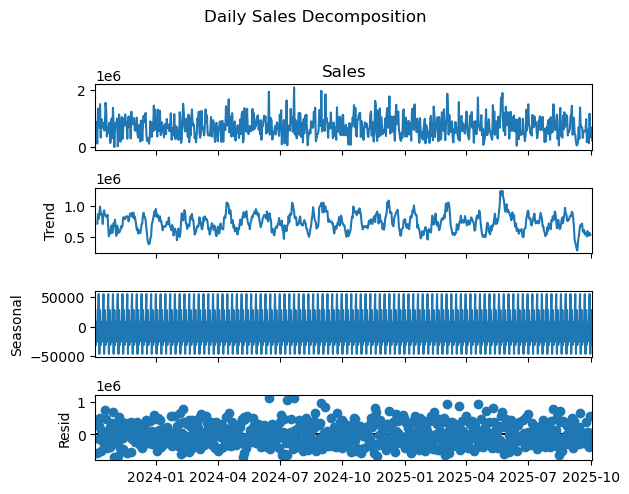

In [17]:
result_daily = seasonal_decompose(daily_sales, model='additive', period=7)
result_daily.plot()
plt.suptitle('Daily Sales Decomposition', y=1.02)
plt.tight_layout()
plt.show()

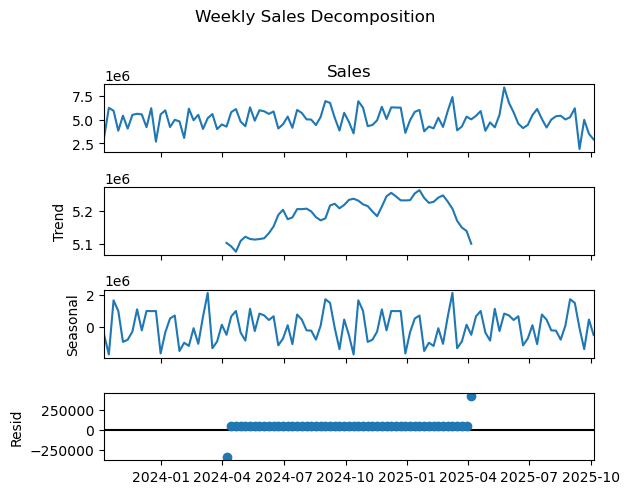

In [18]:
result_weekly = seasonal_decompose(weekly_sales, model='additive', period=52)
result_weekly.plot()
plt.suptitle('Weekly Sales Decomposition', y=1.02)
plt.tight_layout()
plt.show()

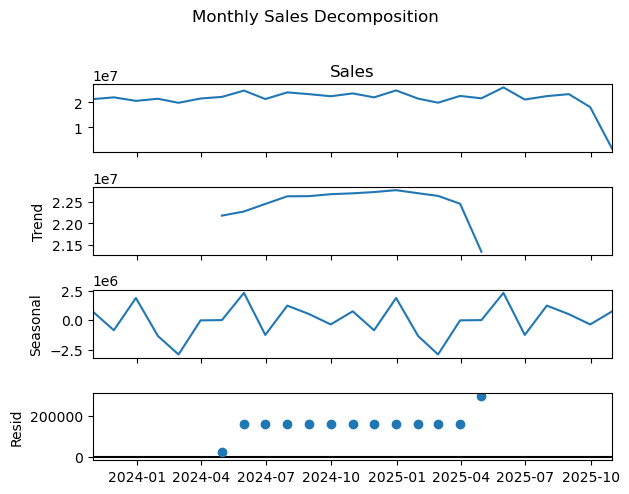

In [19]:
result_monthly = seasonal_decompose(monthly_sales, model='additive', period=12)
result_monthly.plot()
plt.suptitle('Monthly Sales Decomposition', y=1.02)
plt.tight_layout()
plt.show()

Build a Simple Moving Average Forecast

monthly_sales_ma = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Actual Sales')
plt.plot(monthly_sales_ma, label='3-Month Moving Average', color='red')
plt.legend()
plt.title('Monthly Sales Trend with Moving Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

forecast_next_month = monthly_sales[-3:].mean()
print(f"Forecast for next month: {forecast_next_month:.2f}")

Prepare Features for Clustering (Scale using StandardScaler)

In [20]:
features = df[['Sales', 'Profit', 'Quantity', 'Discount']]

In [21]:
print(features.isnull().sum())
features = features.dropna()

Sales       0
Profit      0
Quantity    0
Discount    0
dtype: int64


In [22]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print(scaled_features[:5])

[[-1.17832153 -1.02154993 -1.41019947 -0.00719937]
 [-0.58620896 -0.78421549  0.00523712 -1.41884046]
 [-1.03660539 -0.91754954  0.00523712  1.40444172]
 [-0.79562216 -0.60299271 -1.41019947 -1.41884046]
 [-0.53193145 -0.33020761 -1.41019947 -1.41884046]]


 Apply K-Means Clustering

In [23]:
optimal_k = 4

In [24]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

In [25]:
features['Cluster'] = cluster_labels

In [26]:
print(features.head())
print(features['Cluster'].value_counts())

              Sales    Profit  Quantity  Discount  Cluster
Order Date                                                
2023-10-04   6458.4    724.54         1        10        3
2023-10-04  56847.0   4259.92         3         0        0
2023-10-04  18518.4   2273.75         3        20        3
2023-10-04  39026.0   6959.45         1         0        0
2023-10-04  61466.0  11022.91         1         0        0
Cluster
3    1393
1    1319
0    1306
2     982
Name: count, dtype: int64


 Visualize Clusters Using PCA (2D Plot)

In [27]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

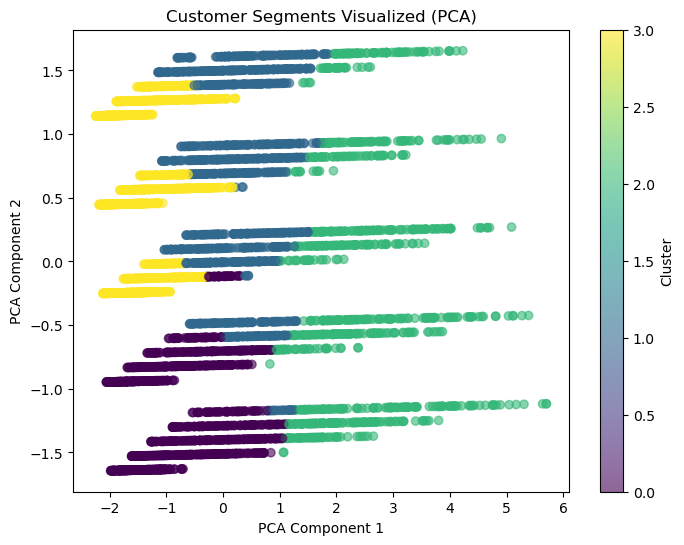

In [28]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments Visualized (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.show()

Profile Each Segment with Recommendations

In [29]:
cluster_profile = features.groupby('Cluster')[['Sales', 'Profit', 'Quantity', 'Discount']].mean()
print(cluster_profile)

                 Sales        Profit  Quantity   Discount
Cluster                                                  
0         68259.483499   9772.972703  2.264931   2.450230
1        108212.882866  14523.456096  4.053071  13.684610
2        241285.960336  39204.043310  4.360489   7.729124
3         46549.557322   6669.363561  1.706389  15.373295


Define Target Variable

In [30]:
target = 'Sales'

In [31]:
feature_cols = ['Quantity', 'Unit Price', 'Discount', 'Profit']

In [32]:
X = df[feature_cols]   
y = df[target]

In [33]:
print(X.head())
print(y.head())

            Quantity  Unit Price  Discount    Profit
Order Date                                          
2023-10-04         1        7176        10    724.54
2023-10-04         3       18949         0   4259.92
2023-10-04         3        7716        20   2273.75
2023-10-04         1       39026         0   6959.45
2023-10-04         1       61466         0  11022.91
Order Date
2023-10-04     6458.4
2023-10-04    56847.0
2023-10-04    18518.4
2023-10-04    39026.0
2023-10-04    61466.0
Name: Sales, dtype: float64


Split Data into Train/Test (80/20)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (4000, 4)
Testing data size: (1000, 4)


Build Linear Regression Model

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [37]:
y_pred = model.predict(X_test)
print(y_pred[:10]) 

[139538.00301168  99248.86092838 204903.65265422  44768.40865789
  66246.929107   105289.56019349  84440.72620379   7068.86616837
  63890.18526067 154693.94265196]


In [38]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [39]:
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.914
MAE: 19728.22
RMSE: 25643.15


 Identify Top 3 Important Features

In [40]:
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
})

In [41]:
importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Coefficient', ascending=False)

In [42]:
print(importance)
print("\nTop 3 Most Important Features:")
print(importance.head(3))

      Feature   Coefficient  Abs_Coefficient
0    Quantity  27603.261776     27603.261776
2    Discount   -888.510410       888.510410
1  Unit Price      2.064309         2.064309
3      Profit      1.576680         1.576680

Top 3 Most Important Features:
      Feature   Coefficient  Abs_Coefficient
0    Quantity  27603.261776     27603.261776
2    Discount   -888.510410       888.510410
1  Unit Price      2.064309         2.064309
